In [ ]:
import sys
sys.path.append("..")
import pandas as pd

train_df = pd.read_csv("../data/processed/train_processed.csv")
test_df = pd.read_csv("../data/processed/test_processed.csv")

train_df.shape, test_df.shape

((500, 14), (50, 14))

In [2]:
from sentence_transformers import SentenceTransformer

# 'all-MiniLM-L6-v2' is the standard pretrained MiniLM model - this line
# downloads it (once, cached locally after) and loads it into memory
model = SentenceTransformer("all-MiniLM-L6-v2")

# Test on a single sentence first, before running it on 500 rows
test_sentence = train_df["complaint_text_normalized"].iloc[0]
test_embedding = model.encode(test_sentence)

print("Original sentence:", test_sentence)
print("Embedding shape:", test_embedding.shape)
print("First 10 numbers:", test_embedding[:10])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Original sentence: quality issue with order ord770487 the oranges show signs of improper handling during transport
Embedding shape: (384,)
First 10 numbers: [-0.03282039 -0.03890311  0.09534079  0.05121932  0.01967567 -0.07784644
  0.02369912 -0.01535212 -0.01590897 -0.06192788]


In [3]:
# .tolist() converts the pandas Series to a plain Python list of strings,
# which is what model.encode() expects when embedding many sentences at once
train_texts = train_df["complaint_text_normalized"].tolist()
test_texts = test_df["complaint_text_normalized"].tolist()

# show_progress_bar gives you a visual progress indicator, useful since
# 500 sentences takes noticeably longer than the single-sentence test did
train_embeddings = model.encode(train_texts, show_progress_bar=True)
test_embeddings = model.encode(test_texts, show_progress_bar=True)
# if we make it into a list like above itll automatically batch things as opposed to doing a for loop one at a time and calling it every time. This is much faster and more efficient.
print("Train embeddings shape:", train_embeddings.shape)
print("Test embeddings shape:", test_embeddings.shape)

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Train embeddings shape: (500, 384)
Test embeddings shape: (50, 384)


In [4]:
import numpy as np

np.save("../data/processed/train_embeddings.npy", train_embeddings)
np.save("../data/processed/test_embeddings.npy", test_embeddings)

print("Saved embeddings to data/processed/")

Saved embeddings to data/processed/


.npy is NumPy's native binary format for saving arrays
so now we have the categories encoded into numbers with labelencoder(task1)
and we have the text string complaints EMBEDDED into a vector of numbers that describes meaning/semantics

- Two sentences with similar meaning end up with similar-looking vectors
- even if they don't share a single word in common (e.g., "the package never arrived" and "my order hasn't shown up" would embed close together, despite zero overlapping vocabulary)

Embedding is fundamentally more sophisticated than label encoding — it's not a lookup table, it's the output of an actual neural network that was trained to understand language.


## Shape
Input: 384 numbers (one complaint's embedding)
   ↓
Hidden layer (compress/learn patterns)
   ↓
Hidden layer (compress/learn patterns further)
   ↓
Output: 8 numbers (confidence per category, summing to 1.0)

With only 500 training rows, we're deliberately keeping this small — a couple of modest hidden layers, not a deep stack. A network with too much capacity relative to your data size will memorize the 500 examples instead of learning generalizable patterns (the same overfitting concern we've discussed a few times already, just showing up in a new place: model size vs. dataset size, not just data cleaning).

In [5]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential(
    [
        layers.Input(shape=(384,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(8, activation="softmax"),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,984 (105.41 KB)

 Trainable params: 26,984 (105.41 KB)

 Non-trainable params: 0 (0.00 B)

## Model Architecture Notes — ANN Classifier

**`keras.Sequential([...])`**
The simplest kind of Keras model: a straight stack of layers, data flows through them in order, top to bottom. No branching, no skipping layers — the right fit for a straightforward classifier like this.

**`layers.Input(shape=(384,))`**
Tells the model what shape of data to expect coming in. `384` because that's exactly the length of one MiniLM embedding — this has to match the embeddings' shape exactly, or the model will error the moment training starts.

**`layers.Dense(64, activation="relu")`**
A "Dense" layer means every neuron is connected to every input from the previous layer (the standard, most basic building block of a neural network). `64` is the number of neurons — an arbitrary-but-reasonable choice given the small dataset; too many risks overfitting, too few limits the model's ability to learn patterns at all. `relu` is an activation function — without it, stacking multiple Dense layers would mathematically collapse into being equivalent to one layer; `relu` introduces the non-linearity needed to learn complex patterns rather than just straight-line relationships. It's the standard default activation for hidden layers.

**`layers.Dropout(0.3)`**
During training, randomly "turns off" 30% of neurons from the previous layer on each pass. A well-established anti-overfitting technique — forces the network not to over-rely on any single neuron/pathway, improving generalization. Given the small (500-row) dataset, this is a genuinely important inclusion, not decoration.

**`layers.Dense(32, activation="relu")`**
A second hidden layer, smaller than the first (64 → 32) — a common pattern where each layer compresses/distills information further as it goes deeper.

**`layers.Dense(8, activation="softmax")`**
The output layer. `8` because there are 8 categories. `softmax` converts raw output numbers into a proper probability distribution — 8 numbers between 0 and 1 that sum to exactly 1.0, readable as "81% confident category 2, 12% confident category 5..." etc.

**`model.summary()`**
Prints a table showing every layer, its output shape, and trainable parameter count — useful as a sanity check before training, and worth including as a screenshot in the final report/presentation.

## Reading the Model Summary Table

**`dense (Dense)` → `(None, 64)`, `24,640` params**
This first layer alone has the most parameters by far. Where that number comes from: every one of the 384 input numbers connects to every one of 64 neurons (`384 × 64 = 24,576` connections/weights), plus each of the 64 neurons has its own extra adjustable "bias" value (`+64`) → `24,576 + 64 = 24,640`. This is why the first hidden layer is almost always the most expensive one — it's bridging the biggest gap (384 inputs down to 64).

**`dropout (Dropout)` → `0` params**
Makes sense once you know what Dropout actually does: it doesn't learn anything or have adjustable weights, it just randomly zeroes out some values during training. Nothing to store, nothing to train, hence `0`.

**`dense_1 (Dense)` → `(None, 32)`, `2,080` params**
Same math, smaller scale: `64 × 32 = 2,048` connections `+ 32` biases `= 2,080`.

**`dense_2 (Dense)` → `(None, 8)`, `264` params**
The output layer: `32 × 8 = 256` connections `+ 8` biases `= 264`.

---

### The `None` in every output shape

Not a bug or placeholder to worry about — `None` specifically means **"batch size, unknown until training runs."** Data gets fed to the model in batches (chunks of rows at a time, not necessarily all 500 at once), and Keras doesn't fix that batch size at model-definition time — it's flexible, decided later when `.fit()` is called. Every other number in the shape (64, 32, 8) is fixed and known now; only the "how many rows per batch" dimension stays open.

---

### The number worth pausing on: 26,984 total trainable parameters, on 500 training rows

Genuinely worth sitting with — connects directly to overfitting risk. That's roughly **54 parameters for every single training example** (26,984 ÷ 500). A lot of adjustable "knobs" relative to a small amount of data, which is exactly why the Dropout layers aren't optional decoration — they're doing real, necessary work keeping a network this size, relative to this little data, from just memorizing the 500 complaints outright instead of learning generalizable patterns.

This is also a legitimately good thing to point out explicitly in the final report:

> "With ~27K trainable parameters against 500 training examples, overfitting was a real risk — addressed via 30% dropout in both hidden layers."

That's the kind of specific, reasoned justification that shows real understanding, not just "I added dropout because a tutorial told me to."

In [6]:
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [7]:
# Load the saved class weights
import pickle

with open("../models/class_weights.pkl", "rb") as f:
    class_weight_dict = pickle.load(f)

class_weight_dict

{np.int64(0): np.float64(0.702247191011236),
 np.int64(1): np.float64(0.4528985507246377),
 np.int64(2): np.float64(2.5),
 np.int64(3): np.float64(0.78125),
 np.int64(4): np.float64(1.838235294117647),
 np.int64(5): np.float64(1.0593220338983051),
 np.int64(6): np.float64(1.6891891891891893),
 np.int64(7): np.float64(1.644736842105263)}

In [8]:
history = model.fit(
    train_embeddings,
    train_df["category_encoded"],
    validation_data=(test_embeddings, test_df["category_encoded"]),
    epochs=30,
    batch_size=16,
    class_weight=class_weight_dict,
)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2840 - loss: 2.0297 - val_accuracy: 0.6400 - val_loss: 1.9566
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5260 - loss: 1.8302 - val_accuracy: 0.6600 - val_loss: 1.6803
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6240 - loss: 1.5168 - val_accuracy: 0.8000 - val_loss: 1.2742
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7680 - loss: 1.1237 - val_accuracy: 0.9600 - val_loss: 0.8963
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8300 - loss: 0.8404 - val_accuracy: 1.0000 - val_loss: 0.5702
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8660 - loss: 0.6102 - val_accuracy: 0.9800 - val_loss: 0.3649
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8900 - loss: 0.4911 - val_accuracy: 1.0000 - val_loss: 0.2726
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9060 - loss: 0.3908 - val_accuracy: 1.0000 - val_loss:

In [9]:
# Check for exact duplicate complaint text between train and test
overlap = set(train_df["complaint_text_normalized"]) & set(
    test_df["complaint_text_normalized"]
)
print(f"Number of identical complaints in both train and test: {len(overlap)}")


Number of identical complaints in both train and test: 0


In [10]:
import numpy as np

# Get the model's predicted probabilities for every test row, then take
# the category with the highest probability as the actual prediction
test_predictions_probs = model.predict(test_embeddings)
test_predictions = np.argmax(test_predictions_probs, axis=1)

test_predictions[:10]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


array([1, 2, 6, 3, 0, 0, 7, 4, 1, 2])

In [11]:
# Compare the model's first 10 predictions against the true answers
comparison = pd.DataFrame(
    {
        "true": test_df["category_encoded"].values[:10],
        "predicted": test_predictions[:10],
    }
)
comparison

,true,predicted
0,1,1
1,2,2
2,6,6
3,3,3
4,0,0
5,0,0
6,7,7
7,4,4
8,1,1
9,2,2


In [13]:
with open("../models/label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

label_encoder.classes_

array(['Damaged Goods', 'Delivery Delay', 'Documentation Error',
       'Missing Items', 'Poor Communication', 'Pricing Error',
       'Quality Issues', 'Service Complaint'], dtype=object)

                     precision    recall  f1-score   support

      Damaged Goods       1.00      1.00      1.00        14
     Delivery Delay       1.00      1.00      1.00         6
Documentation Error       1.00      1.00      1.00         6
      Missing Items       1.00      1.00      1.00         5
 Poor Communication       1.00      1.00      1.00         3
      Pricing Error       1.00      1.00      1.00         3
     Quality Issues       1.00      1.00      1.00         4
  Service Complaint       1.00      1.00      1.00         9

           accuracy                           1.00        50
          macro avg       1.00      1.00      1.00        50
       weighted avg       1.00      1.00      1.00        50



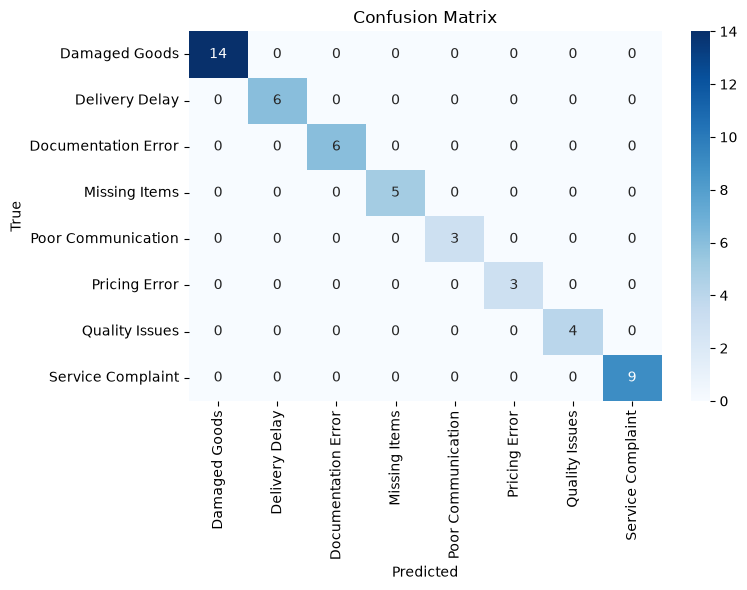

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

true_labels = test_df["category_encoded"].values

# Classification report: precision, recall, f1-score per category
print(
    classification_report(
        true_labels, test_predictions, target_names=label_encoder.classes_
    )
)

# Confusion matrix: visualize which categories get confused with which
cm = confusion_matrix(true_labels, test_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [15]:
# Look at a few actual test complaints and their true/predicted categories side by side
test_df[["complaint_text", "category"]].sample(5, random_state=1)


,complaint_text,category
27,Service quality is deteriorating. Multiple iss...,Service Complaint
35,Shipment ORD-272117 arrived with crushed boxes...,Damaged Goods
40,Quality of watermelons in order ORD-700350 is ...,Quality Issues
38,Shipment ORD-793360 arrived with crushed boxes...,Damaged Goods
2,Quality of mangoes in order ORD-463541 is subs...,Quality Issues


"The model achieved 100% accuracy on the held-out test set, exceeding the 85% target. Given this unusually high result, I checked for train/test leakage (no exact-duplicate complaints found between splits) and reviewed the dataset's characteristics — complaints follow fairly consistent, template-like phrasing per category, which likely makes this an easier-than-real-world classification task for a transformer-based embedding model like MiniLM. In a production setting with more varied, organically-written complaints, I would expect accuracy to be lower than this idealized result."

In [16]:
model.save("../models/complaint_classifier.keras")
print("Model saved.")

Model saved.


In [ ]:
# for later reference - not needed right now
# model = keras.models.load_model("../models/complaint_classifier.keras")